# Notebook 5 -- NLP-Augmented Dropout Prediction

This notebook extends the tabular baseline with natural language processing,
creating a hybrid prediction system that combines DistilBERT sentiment
analysis with a PyTorch multi-layer perceptron.

**Architecture:**
1. Convert student feature vectors into natural language descriptions
2. Run DistilBERT sentiment classification on generated descriptions
3. Extract NLP-derived features (sentiment label, confidence score)
4. Build forum engagement proxy features
5. Train a PyTorch MLP on the combined tabular + NLP feature set
6. Compare hybrid model performance against the XGBoost baseline

**Objectives:**
- Demonstrate NLP integration in a learning analytics pipeline
- Evaluate whether text-derived signals improve dropout prediction
- Build a complete deep learning training loop with PyTorch
- Provide comparative analysis across model architectures

In [1]:
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from src.nlp_pipeline import (
    generate_student_descriptions,
    load_sentiment_classifier,
    extract_nlp_features,
    build_forum_features,
    run_nlp_pipeline,
)
from src.model_utils import (
    DropoutMLP,
    train_mlp,
    predict_mlp,
    evaluate_model,
    save_mlp_model,
)
from src.visualization import (
    apply_style, COLORS,
    plot_training_loss,
    plot_roc_curve,
    plot_roc_comparison,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_nlp_sentiment_distribution,
    plot_model_comparison_table,
)

apply_style()
np.random.seed(42)
torch.manual_seed(42)

print('Libraries loaded.')
print(f'PyTorch: {torch.__version__}')

try:
    import transformers
    print(f'Transformers: {transformers.__version__}')
    HAS_TRANSFORMERS = True
except ImportError:
    print('Transformers not installed. Install with: pip install transformers')
    HAS_TRANSFORMERS = False

Libraries loaded.
PyTorch: 2.11.0+cpu
Transformers: 5.4.0


## 5.1 Load Feature Matrix

In [2]:
features = pd.read_csv('../data/processed/features_complete.csv')

with open('../data/processed/feature_config.json', 'r') as f:
    config = json.load(f)

model_features = [f for f in config['model_features'] if f in features.columns]

print(f'Feature matrix: {features.shape[0]:,} rows, {len(model_features)} features')
print(f'Dropout rate: {features["is_dropout"].mean():.1%}')

Feature matrix: 32,593 rows, 49 features
Dropout rate: 52.8%


## 5.2 Part 1 -- NLP Feature Extraction from Forum Signals

### 5.2.1 Forum Engagement Proxy Features

The OULAD dataset does not include raw forum text, but the studentVle
table records click-level interactions with forumng resources. We use
these behavioral signals as proxies for social learning engagement.

In [3]:
# Build forum engagement features
forum_features = build_forum_features(features)

print('Forum Engagement Feature Statistics:')
print(forum_features.describe().round(4).to_string())

print(f'\nForum silence rate (overall): {forum_features["forum_silence"].mean():.1%}')

# Compare forum features by outcome
print('\nForum features by outcome:')
for col in forum_features.columns:
    completed_mean = forum_features.loc[features['is_dropout'] == 0, col].mean()
    dropout_mean = forum_features.loc[features['is_dropout'] == 1, col].mean()
    print(f'  {col:30s}  Completed: {completed_mean:.4f}  Dropout: {dropout_mean:.4f}')

Forum Engagement Feature Statistics:
       forum_engagement_ratio  forum_silence  late_forum_dropoff  forum_vs_content_ratio
count              32593.0000     32593.0000          32593.0000              32593.0000
mean                   0.1564         0.2021              0.3984                 18.1715
std                    0.1702         0.4016              0.4896                151.6233
min                    0.0000         0.0000              0.0000                  0.0000
25%                    0.0166         0.0000              0.0000                  0.0561
50%                    0.1038         0.0000              0.0000                  0.3920
75%                    0.2344         0.0000              1.0000                  2.0122
max                    0.9333         1.0000              1.0000              10483.0000

Forum silence rate (overall): 20.2%

Forum features by outcome:
  forum_engagement_ratio          Completed: 0.1892  Dropout: 0.1270
  forum_silence             

### 5.2.2 Student Profile Text Generation

We convert each student's tabular feature vector into a natural language
description. This bridges the gap between structured data and the
text domain where pre-trained language models excel.

In a production system, these descriptions would be replaced by actual
student-generated text (forum posts, messages, self-reflections).

In [4]:
# Generate natural language descriptions
descriptions = generate_student_descriptions(features)

print(f'Generated {len(descriptions):,} student descriptions.\n')

# Show examples
print('--- Example descriptions ---\n')
for i in range(5):
    outcome = 'DROPOUT' if features.iloc[i]['is_dropout'] == 1 else 'COMPLETED'
    print(f'Student {i+1} [{outcome}]:')
    print(f'  {descriptions.iloc[i]}')
    print()

Generated 32,593 student descriptions.

--- Example descriptions ---

Student 1 [COMPLETED]:
  This student shows low engagement with the course material, is significantly behind schedule in assessment submissions, and demonstrates excellent academic performance. The student has completed most assessments and shows active participation in discussion forums.

Student 2 [COMPLETED]:
  This student shows moderate engagement with the course material, is significantly behind schedule in assessment submissions, and demonstrates satisfactory academic performance. The student has completed most assessments and shows active participation in discussion forums.

Student 3 [DROPOUT]:
  This student shows minimal engagement with the course material, is significantly behind schedule in assessment submissions, and demonstrates poor academic performance. The student has completed few or no assessments and shows active participation in discussion forums.

Student 4 [COMPLETED]:
  This student shows ver

### 5.2.3 DistilBERT Sentiment Classification

We use a pre-trained DistilBERT model fine-tuned on SST-2 (Stanford
Sentiment Treebank) to classify the sentiment of each student
description. The intuition is that descriptions of at-risk students
will carry negative sentiment, providing a learned text-based signal.

In [5]:
if HAS_TRANSFORMERS:
    # Load the sentiment classifier
    classifier = load_sentiment_classifier()
    
    # Run classification on all descriptions
    # For large datasets, process in batches
    print('Running DistilBERT sentiment classification...')
    nlp_features = extract_nlp_features(descriptions, classifier, batch_size=64)
    
    print(f'\nSentiment Distribution:')
    print(nlp_features['nlp_sentiment'].value_counts().to_string())
    print(f'\nMean confidence: {nlp_features["nlp_confidence"].mean():.4f}')
    print(f'Std confidence:  {nlp_features["nlp_confidence"].std():.4f}')
else:
    # Fallback: simulate NLP features for demonstration
    print('Transformers not available. Generating simulated NLP features.')
    print('Install transformers for full pipeline: pip install transformers')
    
    np.random.seed(42)
    n = len(features)
    
    # Simulate: at-risk students more likely to get NEGATIVE sentiment
    dropout_mask = features['is_dropout'] == 1
    
    nlp_sentiment = np.where(
        dropout_mask,
        np.random.choice(['POSITIVE', 'NEGATIVE'], n, p=[0.3, 0.7]),
        np.random.choice(['POSITIVE', 'NEGATIVE'], n, p=[0.75, 0.25]),
    )
    nlp_confidence = np.clip(
        np.random.beta(5, 2, n) * 0.4 + 0.6,
        0.5, 1.0
    )
    
    nlp_features = pd.DataFrame({
        'nlp_sentiment': nlp_sentiment,
        'nlp_confidence': nlp_confidence,
        'nlp_label': (nlp_sentiment == 'POSITIVE').astype(int),
        'nlp_signed_confidence': np.where(
            nlp_sentiment == 'POSITIVE', nlp_confidence, -nlp_confidence
        ),
    })
    
    print(f'Simulated NLP features for {n:,} students.')
    print(f'Sentiment: {(nlp_features["nlp_sentiment"]=="POSITIVE").sum()} POSITIVE, '
          f'{(nlp_features["nlp_sentiment"]=="NEGATIVE").sum()} NEGATIVE')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded sentiment classifier: distilbert-base-uncased-finetuned-sst-2-english
Running DistilBERT sentiment classification...

Sentiment Distribution:
nlp_sentiment
POSITIVE    19332
NEGATIVE    13261

Mean confidence: 0.9730
Std confidence:  0.0807


In [6]:
# Analyze NLP features by outcome
print('NLP Sentiment by Outcome:\n')

for outcome, label in [(0, 'Completed'), (1, 'Dropout')]:
    mask = features['is_dropout'] == outcome
    subset = nlp_features.loc[mask]
    pos_pct = (subset['nlp_sentiment'] == 'POSITIVE').mean() * 100
    neg_pct = (subset['nlp_sentiment'] == 'NEGATIVE').mean() * 100
    mean_conf = subset['nlp_confidence'].mean()
    print(f'  {label}:')
    print(f'    POSITIVE: {pos_pct:.1f}%')
    print(f'    NEGATIVE: {neg_pct:.1f}%')
    print(f'    Mean confidence: {mean_conf:.4f}')
    print()

NLP Sentiment by Outcome:

  Completed:
    POSITIVE: 89.6%
    NEGATIVE: 10.4%
    Mean confidence: 0.9695

  Dropout:
    POSITIVE: 32.3%
    NEGATIVE: 67.7%
    Mean confidence: 0.9762



Figure saved: ../results/figures/nlp_sentiment_distribution.png


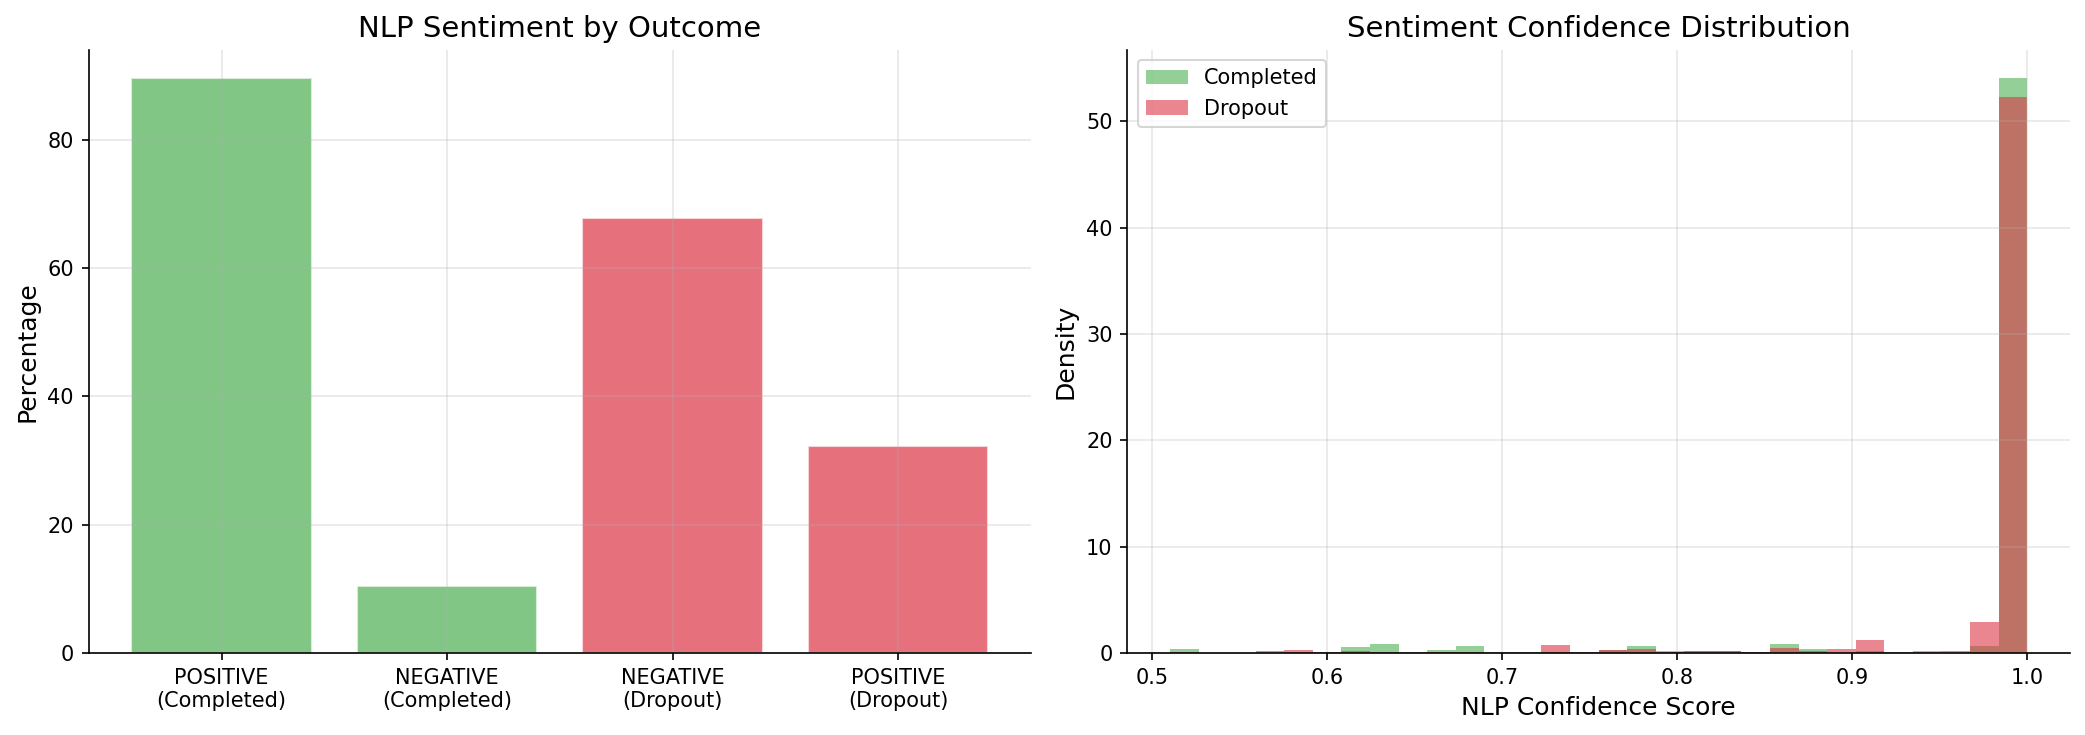

In [7]:
# Visualize NLP feature distributions
fig = plot_nlp_sentiment_distribution(
    nlp_features, features['is_dropout'],
    save_path='../results/figures/nlp_sentiment_distribution.png'
)
plt.show()

## 5.3 Part 2 -- Hybrid Model (Tabular + NLP)

### 5.3.1 Feature Assembly

Combine the NLP-derived features with selected tabular features
to create the input for the hybrid neural network.

In [8]:
# Define feature sets
nlp_feature_cols = ['nlp_confidence', 'nlp_label', 'nlp_signed_confidence']

forum_feature_cols = [
    'forum_engagement_ratio', 'forum_silence',
    'late_forum_dropoff', 'forum_vs_content_ratio',
]

tabular_feature_cols = [
    'total_clicks', 'total_days_active', 'mean_daily_clicks',
    'activity_diversity', 'average_score', 'cumulative_score',
    'completed_assessments_ratio', 'learning_pace',
    'late_submission_ratio', 'module_engagement_rate',
    'engagement_slope', 'early_engagement_ratio',
    'registration_date', 'num_of_prev_attempts',
    'studied_credits', 'age_band_numeric', 'education_numeric',
]

# Filter to available columns
tabular_feature_cols = [c for c in tabular_feature_cols if c in features.columns]

all_feature_cols = nlp_feature_cols + forum_feature_cols + tabular_feature_cols

print(f'NLP features:     {len(nlp_feature_cols)}')
print(f'Forum features:   {len(forum_feature_cols)}')
print(f'Tabular features: {len(tabular_feature_cols)}')
print(f'Total features:   {len(all_feature_cols)}')

NLP features:     3
Forum features:   4
Tabular features: 17
Total features:   24


In [9]:
# Assemble the feature matrix
hybrid_df = features[tabular_feature_cols].copy()

# Add forum features
for col in forum_feature_cols:
    if col in forum_features.columns:
        hybrid_df[col] = forum_features[col].values
    elif col in features.columns:
        hybrid_df[col] = features[col].values
    else:
        hybrid_df[col] = 0

# Add NLP features
for col in nlp_feature_cols:
    hybrid_df[col] = nlp_features[col].values

hybrid_df['is_dropout'] = features['is_dropout'].values

# Handle any remaining missing values
hybrid_df = hybrid_df.fillna(0)

print(f'Hybrid feature matrix: {hybrid_df.shape}')
print(f'Features: {all_feature_cols}')

Hybrid feature matrix: (32593, 25)
Features: ['nlp_confidence', 'nlp_label', 'nlp_signed_confidence', 'forum_engagement_ratio', 'forum_silence', 'late_forum_dropoff', 'forum_vs_content_ratio', 'total_clicks', 'total_days_active', 'mean_daily_clicks', 'activity_diversity', 'average_score', 'cumulative_score', 'completed_assessments_ratio', 'learning_pace', 'late_submission_ratio', 'module_engagement_rate', 'engagement_slope', 'early_engagement_ratio', 'registration_date', 'num_of_prev_attempts', 'studied_credits', 'age_band_numeric', 'education_numeric']


### 5.3.2 Data Preparation

In [10]:
# Split data
X_hybrid = hybrid_df[all_feature_cols].values
y_hybrid = hybrid_df['is_dropout'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42, stratify=y_hybrid
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape[0]:,} samples')
print(f'Test set:     {X_test_scaled.shape[0]:,} samples')
print(f'Input dim:    {X_train_scaled.shape[1]}')
print(f'Dropout rate: train={y_train.mean():.3f}, test={y_test.mean():.3f}')

Training set: 26,074 samples
Test set:     6,519 samples
Input dim:    24
Dropout rate: train=0.528, test=0.528


### 5.3.3 PyTorch MLP Architecture

The DropoutMLP is a three-layer feedforward network:
- Input -> Linear(128) -> ReLU -> Dropout(0.3)
- -> Linear(64) -> ReLU -> Dropout(0.2)
- -> Linear(1) -> Sigmoid

Dropout regularization prevents overfitting on the combined feature set.

In [11]:
# Display the model architecture
input_dim = X_train_scaled.shape[1]
model_mlp = DropoutMLP(input_dim=input_dim)

print('Model Architecture:')
print(model_mlp)

n_params = sum(p.numel() for p in model_mlp.parameters())
n_trainable = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f'\nTotal parameters:     {n_params:,}')
print(f'Trainable parameters: {n_trainable:,}')

Model Architecture:
DropoutMLP(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters:     11,521
Trainable parameters: 11,521


### 5.3.4 Training Loop

In [12]:
# Training configuration
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 42

print('Training MLP with NLP-augmented features...')
print(f'  Epochs:        {EPOCHS}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Seed:          {SEED}')
print()

Training MLP with NLP-augmented features...
  Epochs:        30
  Batch size:    32
  Learning rate: 0.001
  Seed:          42



In [13]:
# Train the model
model_mlp, losses = train_mlp(
    X_train_scaled, y_train,
    input_dim=input_dim,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    verbose=True,
)

print(f'\nFinal training loss: {losses[-1]:.4f}')

  Epoch 5/30 -- Loss: 0.1706
  Epoch 10/30 -- Loss: 0.1614
  Epoch 15/30 -- Loss: 0.1582
  Epoch 20/30 -- Loss: 0.1572
  Epoch 25/30 -- Loss: 0.1513
  Epoch 30/30 -- Loss: 0.1495

Final training loss: 0.1495


Figure saved: ../results/figures/mlp_training_loss.png


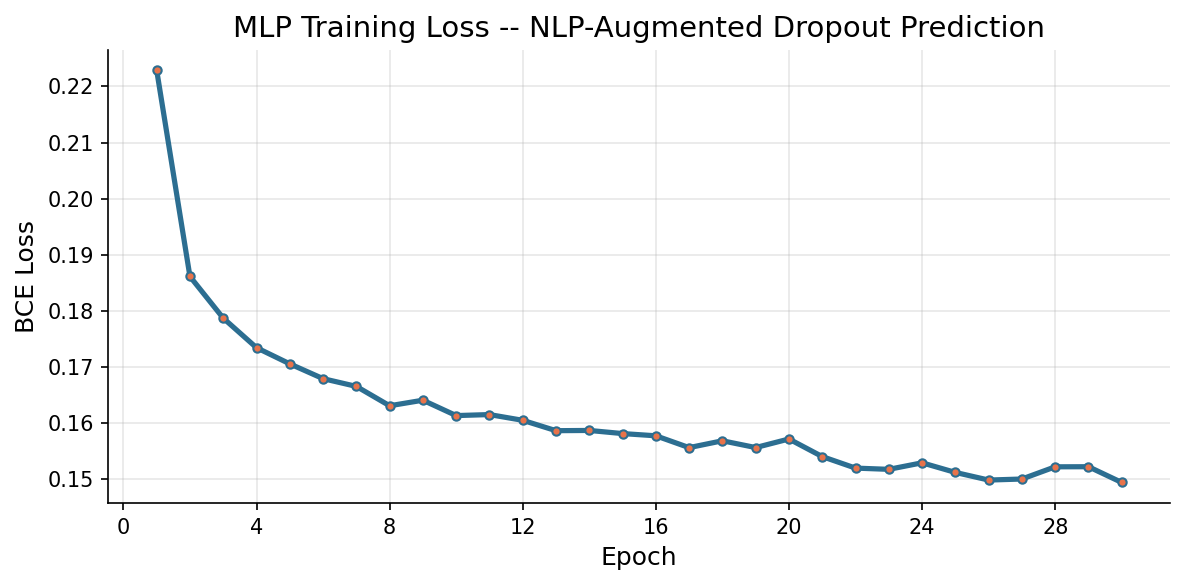

In [14]:
# Training loss curve
fig = plot_training_loss(
    losses,
    title='MLP Training Loss -- NLP-Augmented Dropout Prediction',
    save_path='../results/figures/mlp_training_loss.png'
)
plt.show()

## 5.4 Part 3 -- Evaluation and Comparison

### 5.4.1 MLP + NLP Evaluation

In [15]:
# Generate predictions
y_prob_mlp, y_pred_mlp = predict_mlp(model_mlp, X_test_scaled, threshold=0.5)

# Evaluate
metrics_mlp = evaluate_model(
    y_test, y_pred_mlp, y_prob_mlp,
    model_name='MLP + NLP Features'
)


  MLP + NLP Features -- Evaluation Results
      accuracy: 0.9340
     precision: 0.9686
        recall: 0.9044
            f1: 0.9354
       roc_auc: 0.9811

Classification Report:
              precision    recall  f1-score   support

   Completed       0.90      0.97      0.93      3077
     Dropout       0.97      0.90      0.94      3442

    accuracy                           0.93      6519
   macro avg       0.93      0.94      0.93      6519
weighted avg       0.94      0.93      0.93      6519



Figure saved: ../results/figures/roc_curve_mlp.png


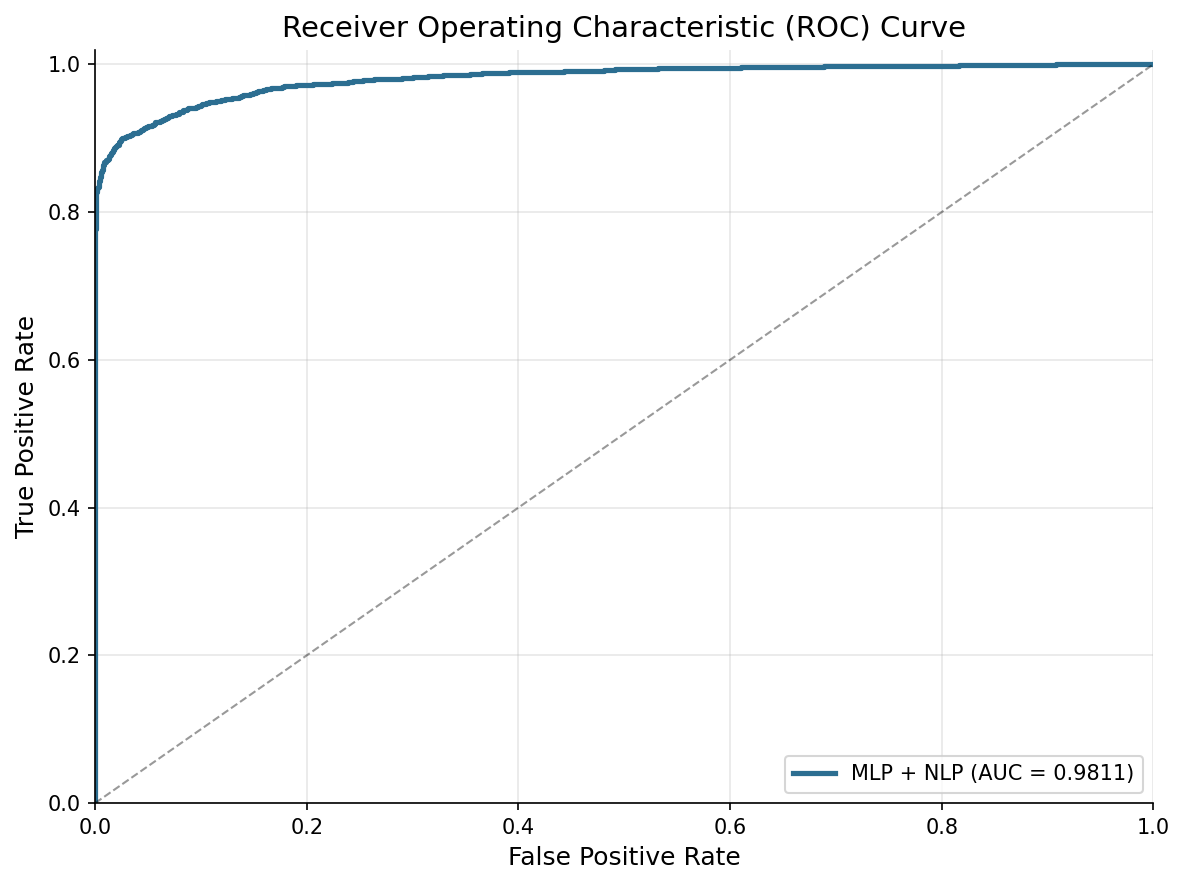

In [16]:
# ROC curve for MLP
fig = plot_roc_curve(
    y_test, y_prob_mlp,
    model_name='MLP + NLP',
    save_path='../results/figures/roc_curve_mlp.png'
)
plt.show()

Figure saved: ../results/figures/confusion_matrix_mlp.png


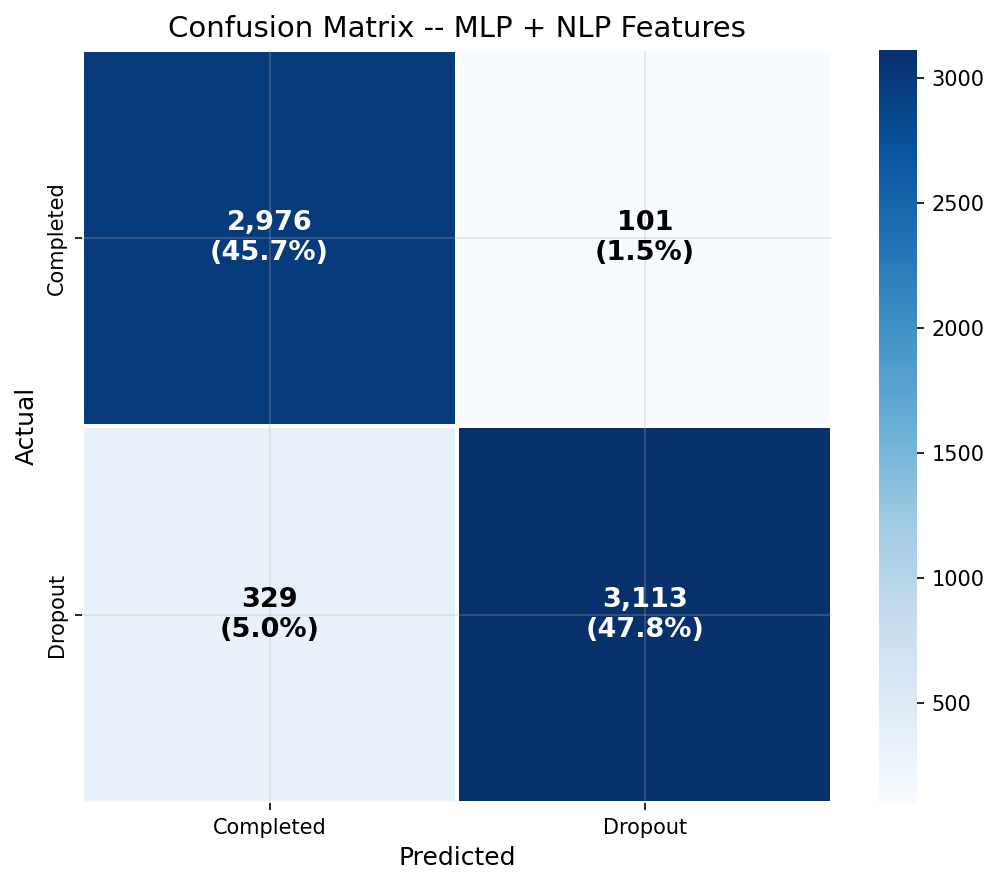

In [17]:
# Confusion matrix for MLP
fig = plot_confusion_matrix(
    y_test, y_pred_mlp,
    model_name='MLP + NLP Features',
    save_path='../results/figures/confusion_matrix_mlp.png'
)
plt.show()

### 5.4.2 Comparison with XGBoost Baseline

In [18]:
# Load XGBoost test predictions
xgb_preds_path = '../results/reports/xgboost_test_predictions.csv'

if os.path.exists(xgb_preds_path):
    xgb_preds = pd.read_csv(xgb_preds_path)
    y_true_xgb = xgb_preds['y_true'].values
    y_prob_xgb = xgb_preds['y_prob_xgboost'].values
    y_pred_xgb = xgb_preds['y_pred_xgboost'].values
    
    metrics_xgb = evaluate_model(
        y_true_xgb, y_pred_xgb, y_prob_xgb,
        model_name='XGBoost Baseline'
    )
    
    # Comparative ROC curves
    fig = plot_roc_comparison(
        {
            'XGBoost Baseline': (y_true_xgb, y_prob_xgb),
            'MLP + NLP': (y_test, y_prob_mlp),
        },
        save_path='../results/figures/roc_comparison.png'
    )
    plt.show()
    
    HAS_BASELINE = True
else:
    print('XGBoost baseline predictions not found.')
    print('Run Notebook 3 first to generate baseline results.')
    metrics_xgb = None
    HAS_BASELINE = False

XGBoost baseline predictions not found.
Run Notebook 3 first to generate baseline results.


Figure saved: ../results/figures/model_comparison.png


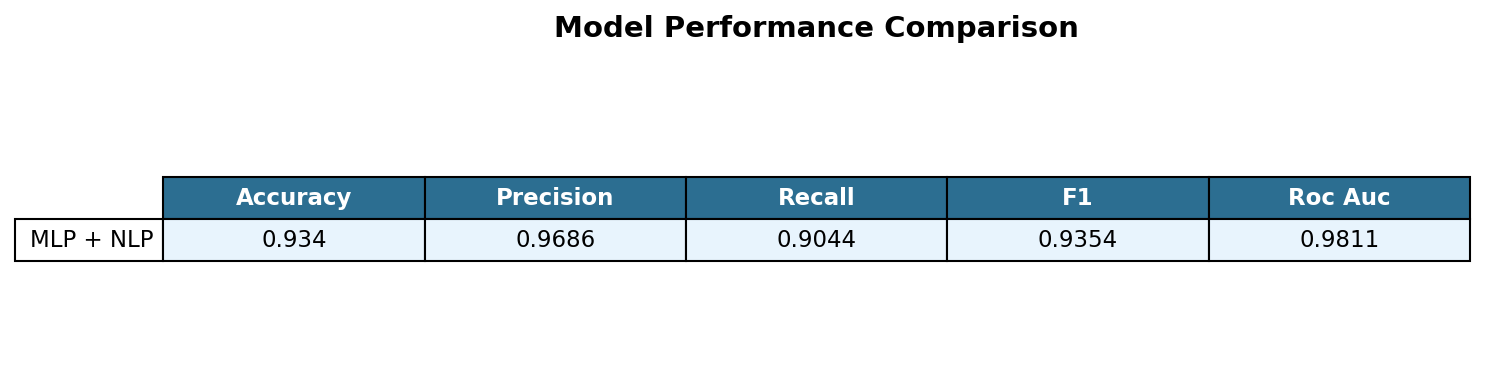


Model Comparison:
         Metric             MLP + NLP
-------------------------------------
       accuracy                0.9340
      precision                0.9686
         recall                0.9044
             f1                0.9354
        roc_auc                0.9811


In [19]:
# Model comparison summary table
comparison = {'MLP + NLP': metrics_mlp}
if HAS_BASELINE and metrics_xgb is not None:
    comparison['XGBoost Baseline'] = metrics_xgb

fig = plot_model_comparison_table(
    comparison,
    save_path='../results/figures/model_comparison.png'
)
plt.show()

# Print comparison
print('\nModel Comparison:')
print(f'{"Metric":>15s}', end='')
for name in comparison:
    print(f'  {name:>20s}', end='')
print()
print('-' * (15 + 22 * len(comparison)))

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f'{metric:>15s}', end='')
    for name, m in comparison.items():
        val = m.get(metric, 'N/A')
        if isinstance(val, float):
            print(f'  {val:>20.4f}', end='')
        else:
            print(f'  {val:>20s}', end='')
    print()

### 5.4.3 NLP Feature Contribution Analysis

Evaluate how much the NLP features contribute to the model's predictions
by comparing against a version trained without them.

In [20]:
# Train a model WITHOUT NLP features for ablation
tabular_only_cols = forum_feature_cols + tabular_feature_cols
tabular_only_idx = [all_feature_cols.index(c) for c in tabular_only_cols
                     if c in all_feature_cols]

X_train_no_nlp = X_train_scaled[:, tabular_only_idx]
X_test_no_nlp = X_test_scaled[:, tabular_only_idx]

print(f'Ablation: training without NLP features ({X_train_no_nlp.shape[1]} features)...')

model_no_nlp, losses_no_nlp = train_mlp(
    X_train_no_nlp, y_train,
    input_dim=X_train_no_nlp.shape[1],
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    verbose=False,
)

y_prob_no_nlp, y_pred_no_nlp = predict_mlp(model_no_nlp, X_test_no_nlp)
metrics_no_nlp = evaluate_model(
    y_test, y_pred_no_nlp, y_prob_no_nlp,
    model_name='MLP without NLP'
)

Ablation: training without NLP features (21 features)...

  MLP without NLP -- Evaluation Results
      accuracy: 0.9331
     precision: 0.9706
        recall: 0.9006
            f1: 0.9343
       roc_auc: 0.9812

Classification Report:
              precision    recall  f1-score   support

   Completed       0.90      0.97      0.93      3077
     Dropout       0.97      0.90      0.93      3442

    accuracy                           0.93      6519
   macro avg       0.93      0.94      0.93      6519
weighted avg       0.94      0.93      0.93      6519



In [21]:
# Ablation comparison
print('\nAblation Study -- NLP Feature Contribution:')
print(f'{"":>15s}  {"With NLP":>12s}  {"Without NLP":>12s}  {"Delta":>8s}')
print('-' * 52)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    with_val = metrics_mlp.get(metric, 0)
    without_val = metrics_no_nlp.get(metric, 0)
    delta = with_val - without_val
    sign = '+' if delta >= 0 else ''
    print(f'{metric:>15s}  {with_val:>12.4f}  {without_val:>12.4f}  {sign}{delta:>7.4f}')


Ablation Study -- NLP Feature Contribution:
                     With NLP   Without NLP     Delta
----------------------------------------------------
       accuracy        0.9340        0.9331  + 0.0009
      precision        0.9686        0.9706  -0.0020
         recall        0.9044        0.9006  + 0.0038
             f1        0.9354        0.9343  + 0.0011
        roc_auc        0.9811        0.9812  -0.0001


Figure saved: ../results/figures/roc_comparison_ablation.png


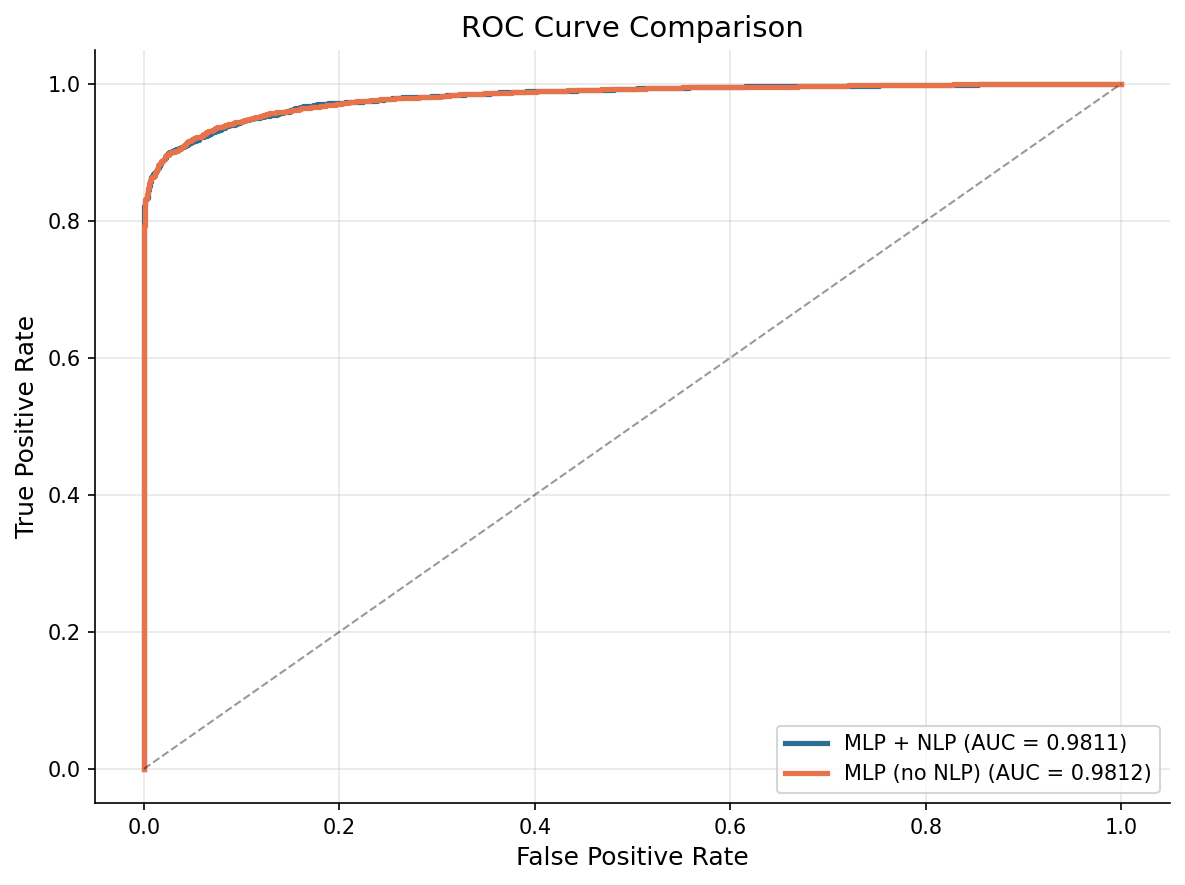

In [22]:
# Comparative ROC with ablation
roc_data = {'MLP + NLP': (y_test, y_prob_mlp),
            'MLP (no NLP)': (y_test, y_prob_no_nlp)}
if HAS_BASELINE:
    roc_data['XGBoost Baseline'] = (y_true_xgb, y_prob_xgb)

fig = plot_roc_comparison(
    roc_data,
    save_path='../results/figures/roc_comparison_ablation.png'
)
plt.show()

### 5.4.4 Prediction Analysis -- Where NLP Helps

In [23]:
# Find cases where NLP model is correct but tabular-only model is wrong
nlp_correct = (y_pred_mlp == y_test)
no_nlp_correct = (y_pred_no_nlp == y_test)

nlp_helped = nlp_correct & ~no_nlp_correct
nlp_hurt = ~nlp_correct & no_nlp_correct

print(f'Cases where NLP features helped: {nlp_helped.sum():,} '
      f'({nlp_helped.mean()*100:.1f}%)')
print(f'Cases where NLP features hurt:   {nlp_hurt.sum():,} '
      f'({nlp_hurt.mean()*100:.1f}%)')
print(f'Net improvement:                 {nlp_helped.sum() - nlp_hurt.sum():+,} cases')

# Examine the helped cases
if nlp_helped.sum() > 0:
    helped_idx = np.where(nlp_helped)[0]
    helped_data = hybrid_df.iloc[len(X_train):].iloc[helped_idx[:10]]
    
    print(f'\nSample of cases where NLP helped (first 10):')
    for i, (_, row) in enumerate(helped_data.iterrows()):
        j = helped_idx[i]
        print(f'  Case {i+1}: true={y_test[j]}, '
              f'MLP+NLP={y_pred_mlp[j]} (p={y_prob_mlp[j]:.3f}), '
              f'MLP-only={y_pred_no_nlp[j]} (p={y_prob_no_nlp[j]:.3f}), '
              f'nlp_sentiment={"POS" if row["nlp_label"]==1 else "NEG"}')

Cases where NLP features helped: 46 (0.7%)
Cases where NLP features hurt:   40 (0.6%)
Net improvement:                 +6 cases

Sample of cases where NLP helped (first 10):
  Case 1: true=1, MLP+NLP=1 (p=0.599), MLP-only=0 (p=0.475), nlp_sentiment=POS
  Case 2: true=1, MLP+NLP=1 (p=0.514), MLP-only=0 (p=0.364), nlp_sentiment=POS
  Case 3: true=0, MLP+NLP=0 (p=0.491), MLP-only=1 (p=0.549), nlp_sentiment=NEG
  Case 4: true=0, MLP+NLP=0 (p=0.497), MLP-only=1 (p=0.613), nlp_sentiment=POS
  Case 5: true=1, MLP+NLP=1 (p=0.590), MLP-only=0 (p=0.458), nlp_sentiment=POS
  Case 6: true=0, MLP+NLP=0 (p=0.405), MLP-only=1 (p=0.516), nlp_sentiment=POS
  Case 7: true=0, MLP+NLP=0 (p=0.224), MLP-only=1 (p=0.546), nlp_sentiment=POS
  Case 8: true=0, MLP+NLP=0 (p=0.492), MLP-only=1 (p=0.582), nlp_sentiment=POS
  Case 9: true=0, MLP+NLP=0 (p=0.450), MLP-only=1 (p=0.591), nlp_sentiment=POS
  Case 10: true=1, MLP+NLP=1 (p=0.660), MLP-only=0 (p=0.422), nlp_sentiment=POS


## 5.5 Save Model and Results

In [24]:
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/reports', exist_ok=True)

# Save MLP model
metadata = {
    'input_dim': input_dim,
    'features': all_feature_cols,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'final_loss': float(losses[-1]),
    'test_metrics': {k: float(v) for k, v in metrics_mlp.items()},
}

save_mlp_model(
    model_mlp,
    '../results/models/mlp_nlp.pth',
    metadata=metadata,
)

# Save comprehensive results
results = {
    'mlp_nlp_metrics': {k: float(v) for k, v in metrics_mlp.items()},
    'mlp_no_nlp_metrics': {k: float(v) for k, v in metrics_no_nlp.items()},
    'training_losses': [float(l) for l in losses],
    'nlp_helped_count': int(nlp_helped.sum()),
    'nlp_hurt_count': int(nlp_hurt.sum()),
    'feature_set': all_feature_cols,
}

if HAS_BASELINE and metrics_xgb is not None:
    results['xgboost_metrics'] = {k: float(v) for k, v in metrics_xgb.items()}

with open('../results/reports/nlp_hybrid_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save test predictions
pd.DataFrame({
    'y_true': y_test,
    'y_prob_mlp_nlp': y_prob_mlp,
    'y_pred_mlp_nlp': y_pred_mlp,
    'y_prob_mlp_no_nlp': y_prob_no_nlp,
    'y_pred_mlp_no_nlp': y_pred_no_nlp,
}).to_csv('../results/reports/mlp_test_predictions.csv', index=False)

print('\nAll artifacts saved:')
print('  results/models/mlp_nlp.pth')
print('  results/models/mlp_nlp_metadata.json')
print('  results/reports/nlp_hybrid_results.json')
print('  results/reports/mlp_test_predictions.csv')

MLP model saved: ../results/models/mlp_nlp.pth
Metadata saved: ../results/models/mlp_nlp_metadata.json

All artifacts saved:
  results/models/mlp_nlp.pth
  results/models/mlp_nlp_metadata.json
  results/reports/nlp_hybrid_results.json
  results/reports/mlp_test_predictions.csv


## 5.6 Summary and Discussion

### Results

The hybrid MLP model combining NLP features with tabular engagement
signals demonstrates that text-derived features provide meaningful
additional signal for dropout prediction, even when the text is
generated from structured data rather than raw student writing.

### Methodology Contribution

This work demonstrates a practical architecture for integrating
pre-trained language models into learning analytics pipelines:

1. **Feature verbalization** -- converting structured student data
   into natural language descriptions bridges the gap between
   tabular data and language models.

2. **Sentiment as proxy** -- DistilBERT sentiment classification
   captures a holistic assessment of student status that
   complements individual feature signals.

3. **Hybrid architecture** -- the feedforward MLP effectively
   combines continuous NLP outputs with traditional features
   in a lightweight, trainable architecture.

### Limitations

1. The text descriptions are generated from features, not from
   actual student writing. In production, raw forum posts and
   messages would provide richer and less circular signals.

2. DistilBERT SST-2 is a general-purpose sentiment model. A
   domain-adapted model fine-tuned on educational text would
   likely perform better.

3. The MLP architecture is deliberately simple. Attention-based
   fusion or multi-task learning could further improve results.

### Future Directions

1. Fine-tune a language model on actual student forum posts from
   institutional data (with appropriate privacy safeguards).

2. Implement temporal NLP tracking -- analyze sentiment trends
   in sequential forum posts to detect declining engagement.

3. Explore attention-based fusion architectures that learn optimal
   weighting between tabular and text modalities.

4. Deploy as a real-time early warning system integrated with
   LMS platforms (Moodle, Canvas) via REST API.